In [1]:
from jqdata import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime
import warnings
from tqdm import tqdm
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.data import TensorDataset

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体设置-黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
today = str(datetime.datetime.today().date())

# 获取所有ETF，过滤流动性较差的

In [2]:
#获得etf基金列表
df = get_all_securities(['etf'])
df = df.reset_index().rename(columns={'index':'code'})
df = df[df['start_date'] < datetime.date(2021, 1, 1)]
df = df[df['end_date'] >= datetime.datetime.today().date()]

In [3]:
# 剔除成交额过低（流动性差）的etf
codes = []
for code in df.code:
    price = get_price(code, end_date=today, count=300).dropna()
    price['pchg'] = price['close'].pct_change()
    if price['money'].mean() > 1e7: # 日均低于5000w成交额
        codes.append([code, price['money'].mean()/1e8, price['pchg'].mean(), price['pchg'].std()])
    else:
        print(f"排除{code} {df[df['code']==code]['display_name'].iloc[0]}, 成交额均值 {round(price['money'].mean()/1e7, 2)}kw")
codes = pd.DataFrame(codes, columns=['code', 'money','pchg_mean','pchg_std'])
df = df.merge(codes, how='inner', on='code')

排除159804.XSHE 创中盘88ETF, 成交额均值 0.03kw
排除159808.XSHE 创100ETF融通, 成交额均值 0.19kw
排除159810.XSHE 创业板ETF浦银, 成交额均值 0.27kw
排除159811.XSHE 5G50ETF, 成交额均值 0.84kw
排除159812.XSHE 黄金基金ETF, 成交额均值 0.09kw
排除159820.XSHE 中证500ETF天弘, 成交额均值 0.67kw
排除159821.XSHE BOCI创业板ETF, 成交额均值 0.01kw
排除159822.XSHE 新经济ETF, 成交额均值 0.25kw
排除159827.XSHE 农业50ETF, 成交额均值 0.2kw
排除159906.XSHE 深成长龙头ETF, 成交额均值 0.32kw
排除159909.XSHE TMT50ETF, 成交额均值 0.28kw
排除159910.XSHE 基本面120ETF, 成交额均值 0.35kw
排除159912.XSHE 深300ETF, 成交额均值 0.15kw
排除159913.XSHE 深价值ETF, 成交额均值 0.04kw
排除159916.XSHE 深F60ETF, 成交额均值 0.18kw
排除159918.XSHE 中创400ETF, 成交额均值 0.03kw
排除159923.XSHE 中证100ETF, 成交额均值 0.02kw
排除159931.XSHE 金融ETF, 成交额均值 0.14kw
排除159933.XSHE 国投金融地产ETF, 成交额均值 0.01kw
排除159935.XSHE 中证500ETF景顺, 成交额均值 0.09kw
排除159936.XSHE 可选消费ETF, 成交额均值 0.44kw
排除159940.XSHE 金融地产ETF, 成交额均值 0.53kw
排除159943.XSHE 深证成指ETF, 成交额均值 0.89kw
排除159944.XSHE 材料ETF, 成交额均值 0.23kw
排除159945.XSHE 能源ETF基金, 成交额均值 0.83kw
排除159954.XSHE H股ETF, 成交额均值 0.77kw
排除159956.XSHE 创业板ETF建信, 成交额均值 0.07kw
排除159958.XSHE 创

In [4]:
raw_codes = df.sort_values('pchg_std')

# 获取ETF日线数据

In [5]:
prices = []
for code in df.code:
#     price = get_price(code, fields='close',end_date='2024-06-26', count=240)
    price = get_price(code, fields='close',end_date=datetime.datetime.today().date(), count=450)
    price['pchg'] = price['close'].pct_change()
    prices.append(price['pchg'].values)
prices = np.array(prices).T
prices = pd.DataFrame(prices, columns=df.code).iloc[1:]
prices

code,159001.XSHE,159003.XSHE,159005.XSHE,159801.XSHE,159805.XSHE,159806.XSHE,159807.XSHE,159813.XSHE,159814.XSHE,159816.XSHE,159819.XSHE,159825.XSHE,159901.XSHE,159902.XSHE,159903.XSHE,159905.XSHE,159907.XSHE,159908.XSHE,159915.XSHE,159919.XSHE,159920.XSHE,159922.XSHE,159925.XSHE,159928.XSHE,159929.XSHE,159930.XSHE,159934.XSHE,159937.XSHE,159938.XSHE,159939.XSHE,159941.XSHE,159948.XSHE,159949.XSHE,159952.XSHE,159957.XSHE,159959.XSHE,159967.XSHE,159968.XSHE,159972.XSHE,159977.XSHE,...,515060.XSHG,515070.XSHG,515080.XSHG,515100.XSHG,515130.XSHG,515180.XSHG,515210.XSHG,515220.XSHG,515260.XSHG,515280.XSHG,515290.XSHG,515300.XSHG,515310.XSHG,515330.XSHG,515380.XSHG,515390.XSHG,515450.XSHG,515580.XSHG,515600.XSHG,515650.XSHG,515680.XSHG,515700.XSHG,515750.XSHG,515770.XSHG,515790.XSHG,515800.XSHG,515850.XSHG,515880.XSHG,515890.XSHG,515900.XSHG,515950.XSHG,515980.XSHG,518680.XSHG,518800.XSHG,518850.XSHG,518880.XSHG,588000.XSHG,588050.XSHG,588080.XSHG,588090.XSHG
1,-0.00001,0.00000,0.00000,-0.012121,-0.013532,0.000000,-0.010791,-0.012500,-0.006356,-0.000861,-0.010769,-0.024811,-0.016684,-0.014741,-0.016730,-0.030402,0.000000,-0.008597,-0.007585,-0.015144,-0.012270,-0.007486,-0.015334,-0.027723,-0.016949,-0.003333,-0.002655,-0.002630,-0.013889,-0.003984,-0.003205,-0.005372,-0.003752,-0.006276,-0.007101,-0.007383,-0.005042,-0.006735,0.000019,-0.005661,...,-0.004435,-0.013189,-0.006923,-0.008094,-0.014719,-0.007673,-0.011637,-0.000828,-0.007519,-0.009488,-0.011050,-0.007890,-0.015918,-0.015579,-0.015475,-0.014465,-0.010438,-0.006720,-0.007785,-0.033195,-0.004325,0.001652,-0.006114,-0.012248,-0.014040,-0.012552,-0.010742,-0.016185,-0.005968,-0.006932,-0.017969,-0.005556,-0.001573,-0.003453,-0.002087,-0.002367,-0.008982,-0.010070,-0.011134,-0.011033
2,0.00001,0.00000,0.00000,0.036810,0.006859,-0.025126,0.003636,0.037975,-0.010661,0.000565,0.010886,-0.009956,-0.007271,-0.008816,0.007734,-0.003359,-0.024390,-0.008672,-0.007643,-0.003909,-0.018634,-0.004919,-0.006118,-0.004073,0.000616,-0.017559,-0.003727,-0.004747,-0.002561,0.020000,-0.012862,-0.007716,-0.012241,-0.009123,-0.009103,0.005785,-0.011824,-0.005338,-0.000279,-0.009353,...,-0.008909,0.010936,-0.010070,-0.002720,-0.003515,-0.008591,-0.007849,-0.019884,0.022727,-0.003831,-0.002235,-0.000994,-0.004757,-0.005935,-0.003992,-0.003914,-0.003165,-0.005413,0.006103,-0.008584,-0.004344,-0.028041,0.003515,-0.007086,-0.025890,-0.005297,0.004936,0.001175,-0.001715,-0.003490,0.005489,0.011173,-0.004202,-0.003198,-0.004182,-0.004746,0.013092,0.015259,0.015353,0.018256
3,-0.00001,-0.00002,0.00000,-0.015779,-0.014986,-0.006443,-0.007246,-0.015244,-0.002155,0.000105,0.000000,-0.004469,-0.003837,-0.001617,-0.015349,-0.008427,-0.035000,-0.004604,-0.006846,-0.004710,-0.001055,0.000330,-0.003078,-0.011247,0.000000,0.012766,-0.001336,-0.001325,0.001284,-0.009804,-0.001629,-0.006998,-0.002860,-0.003541,-0.003937,-0.004930,-0.006838,0.001305,0.000106,-0.004105,...,0.003371,-0.002404,0.004695,-0.000909,-0.003527,0.003466,0.003956,0.003381,-0.011852,-0.005769,-0.004479,-0.003980,-0.002868,-0.003980,-0.003006,-0.004912,0.002116,0.002721,-0.001733,-0.015584,0.006108,-0.006364,0.003503,-0.003568,0.004651,-0.003195,0.004912,0.011737,-0.002577,0.010508,-0.002730,0.001381,-0.002373,-0.001872,-0.001312,-0.001060,0.005964,0.002004,0.005040,0.000996
4,0.00000,0.00002,0.00000,-0.002004,-0.029046,-0.010376,-0.018248,-0.004644,-0.030238,0.000000,-0.003077,-0.020202,-0.030112,-0.019708,-0.021824,-0.039660,-0.005181,-0.021739,-0.023697,-0.027603,-0.059134,-0.007906,-0.026944,-0.045502,-0.035692,-0.019328,0.012577,0.012205,-0.026923,0.003960,0.029364,-0.021535,-0.027725,-0.023454,-0.021080,-0.006606,-0.012048,-0.008257,0.000183,-0.024320,...,-0.036954,-0.003614,-0.017134,-0.019108,-0.027434,-0.018998,0.002364,-0.021904,-0.010495,-0.026112,-0.028121,-0.015984,-0.032598,-0.027972,-0.029648,-0.027641,-0.014784,-0.020353,-0.005208,-0.042216,-0.009540,-0.011102,-0.008726,-0.025067,-0.019841,-0.023504,-0.021505,-0.003480,-0.0223

# K-Means对ETF走势进行聚类
## 这里切记不要迷恋调参！结果在0.9附近即为合理！主要观察结果分类的合理性

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
x = prices.T
n_clusters = 24
cluster = KMeans(n_clusters=n_clusters,random_state=42)
y_pred = cluster.fit_predict(x)   ## 每个样本所对应的簇的标签
x['cluster_id'] = y_pred
silhouette_score(x, y_pred)

0.8971406518094288

In [7]:
x = x.reset_index().rename(columns={'index':'code'})
# df = df.merge(x[['code','cluster_id']]).sort_values(['cluster_id', 'start_date'])
dff = df.merge(x[['code','cluster_id']]).sort_values(['cluster_id', 'start_date'])

In [8]:
pd.set_option('display.max_rows', None)#显示全部行
pd.set_option('display.max_columns', None)#显示全部列
dff

,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std,cluster_id
76,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,4.238802,1.613819e-04,0.000964,0
0,159001.XSHE,货币ETF,BZJ,2014-10-20,2200-01-01,etf,4.778647,3.351539e-08,0.000012,0
1,159003.XSHE,招商快线ETF,ZSKX,2014-10-20,2200-01-01,etf,0.140709,2.799739e-10,0.000024,0
81,511220.XSHG,城投ETF,CTETF,2014-12-16,2200-01-01,etf,3.212656,1.862541e-04,0.000647,0
2,159005.XSHE,汇添富快钱ETF,TFKQ,2015-01-13,2200-01-01,etf,0.103293,7.725654e-11,0.000012,0
82,511260.XSHG,十年国债,SNGZ,2017-08-24,2200-01-01,etf,3.638543,2.340201e-04,0.001352,0
83,511270.XSHG,10年地债,10NDZ,2018-11-22,2200-01-01,etf,3.401940,2.847845e-04,0.001421,0
77,511020.XSHG,活跃国债,HYGZ,2019-02-22,2200-01-01,etf,4.195697,2.153439e-04,0.001150,0
78,511030.XSHG,公司债,GSZ,2019-03-22,2200-01-01,etf,3.641328,1.264066e-04,0.000507,0
38,159972.XSHE,5年地债ETF,5NDZ,2019-11-08,2200-01-01,etf,0.731738,2.230389e-04,0.000780,0


# 聚类到同一个簇里的ETF，仅保留发行时间最早的，原因如下：
## 1. 成立最早的一般成交额最大，流动性最好
## 2. 成立最早的历史数据最多，做模型训练数据也更多

In [9]:
# 每个簇里面选 成立最早的
df = dff
df = df.groupby('cluster_id').first()

# 然而聚类效果并不能一次解决问题，如下所示还是有部分类似的ETF被保留下来
# 当然了，这个池子也是能用的

In [10]:
df

,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std
cluster_id,,,,,,,,,
0,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,4.238802,0.000161,0.000964
1,159901.XSHE,深证100ETF,S100ETF,2006-04-24,2200-01-01,etf,1.126851,-0.000680,0.011047
2,159939.XSHE,信息技术ETF,XXJS,2015-02-05,2200-01-01,etf,0.448635,-0.000782,0.017355
3,510230.XSHG,金融ETF,JRETF,2011-05-23,2200-01-01,etf,0.466734,0.000373,0.009325
4,512070.XSHG,证券保险,FYETF,2014-07-18,2200-01-01,etf,1.696616,-0.000237,0.012977
5,515000.XSHG,科技ETF,KJETF,2019-08-16,2200-01-01,etf,0.676160,-0.000761,0.014362
6,159929.XSHE,医药ETF,YYETF,2013-09-16,2200-01-01,etf,0.626427,-0.001023,0.012933
7,510050.XSHG,50ETF,50ETF,2005-02-23,2200-01-01,etf,22.539805,-0.000052,0.008196
8,512660.XSHG,军工ETF,JGETF,2016-08-08,2200-01-01,etf,2.656754,-0.000696,0.015752


# （可选）如果想要更精简的池子就继续上武器：相关系数过滤，ETF之间两两计算相关系数，当相关系数超过0.85（我拍的）的ETF对，仅保留成立时间早的

In [11]:
# 再用相关系数聚类一遍
corr = prices[df.code].corr()

codes = df.code.tolist()
union = []
for i in codes:
    for j in codes:
        if i == j:
            continue
        if corr.loc[i, j] > 0.85:
            find = False
            for k in range(len(union)):
                if i in union[k] or j in union[k]:
                    union[k].add(i)
                    union[k].add(j)
                    find = True
            if not find:
                union.append(set([i, j]))

In [12]:
# 同理，仅保留成立最早的
remove = []
for i in union:
    remove += df[df['code'].isin(i)].sort_values('start_date').iloc[1:]['code'].tolist()
print('corr 剔除: ', remove)
df = df[~df['code'].isin(remove)]

corr 剔除:  ['159908.XSHE', '512480.XSHG', '515000.XSHG', '512070.XSHG']


# 看下结果是不是清爽很多

In [13]:
df

,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std
cluster_id,,,,,,,,,
0,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,4.238802,0.000161,0.000964
1,159901.XSHE,深证100ETF,S100ETF,2006-04-24,2200-01-01,etf,1.126851,-0.000680,0.011047
2,159939.XSHE,信息技术ETF,XXJS,2015-02-05,2200-01-01,etf,0.448635,-0.000782,0.017355
3,510230.XSHG,金融ETF,JRETF,2011-05-23,2200-01-01,etf,0.466734,0.000373,0.009325
6,159929.XSHE,医药ETF,YYETF,2013-09-16,2200-01-01,etf,0.626427,-0.001023,0.012933
7,510050.XSHG,50ETF,50ETF,2005-02-23,2200-01-01,etf,22.539805,-0.000052,0.008196
8,512660.XSHG,军工ETF,JGETF,2016-08-08,2200-01-01,etf,2.656754,-0.000696,0.015752
9,513030.XSHG,德国ETF,DG30,2014-09-05,2200-01-01,etf,0.639962,0.000552,0.009914
10,512200.XSHG,地产ETF,FDC,2017-09-25,2200-01-01,etf,2.060199,-0.001128,0.019794


# （可选）如果要构建ETF候选池用于模型训练的，过滤下数据较少的EFT，即把成立晚的ETF剔除，这里我拍的2020年为阈值

# 最终结果里是不是有很多是经常出现在ETF策略里的老熟人，也可以一定程度解释为啥要选这几只ETF组合做策略比较好

In [14]:
# 去掉较晚成立的
remove = df[df['start_date'] > datetime.date(2020, 1, 1)]['code'].tolist()
print('成立时间：剔除2020后成立的', remove)
df = df[~df['code'].isin(remove)]
df

成立时间：剔除2020后成立的 []


,code,display_name,name,start_date,end_date,type,money,pchg_mean,pchg_std
cluster_id,,,,,,,,,
0,511010.XSHG,国债ETF,GZETF,2013-03-25,2200-01-01,etf,4.238802,0.000161,0.000964
1,159901.XSHE,深证100ETF,S100ETF,2006-04-24,2200-01-01,etf,1.126851,-0.000680,0.011047
2,159939.XSHE,信息技术ETF,XXJS,2015-02-05,2200-01-01,etf,0.448635,-0.000782,0.017355
3,510230.XSHG,金融ETF,JRETF,2011-05-23,2200-01-01,etf,0.466734,0.000373,0.009325
6,159929.XSHE,医药ETF,YYETF,2013-09-16,2200-01-01,etf,0.626427,-0.001023,0.012933
7,510050.XSHG,50ETF,50ETF,2005-02-23,2200-01-01,etf,22.539805,-0.000052,0.008196
8,512660.XSHG,军工ETF,JGETF,2016-08-08,2200-01-01,etf,2.656754,-0.000696,0.015752
9,513030.XSHG,德国ETF,DG30,2014-09-05,2200-01-01,etf,0.639962,0.000552,0.009914
10,512200.XSHG,地产ETF,FDC,2017-09-25,2200-01-01,etf,2.060199,-0.001128,0.019794


# 画一下走势图人眼看下是不是相关度比较低，还比较符合预期
## 注意，我的方法只是筛选相关度低，流动性好的ETF，所以结果中会有一些和其他相关低但是常年下跌的，比如医药ETF，房产ETF，我这里没把它从池子里剔除，你做策略回测可以把它剔除掉，不过这也算是引入了未来函数吧？
## 换句话说，如果你的池子里有常年下跌的，但是策略收益仍然可观，那是不是说明策略鲁棒性较好，你也说不准以前一直下跌的ETF未来会不会反转大涨吧？

100%|██████████| 20/20 [00:00<00:00, 58.16it/s]


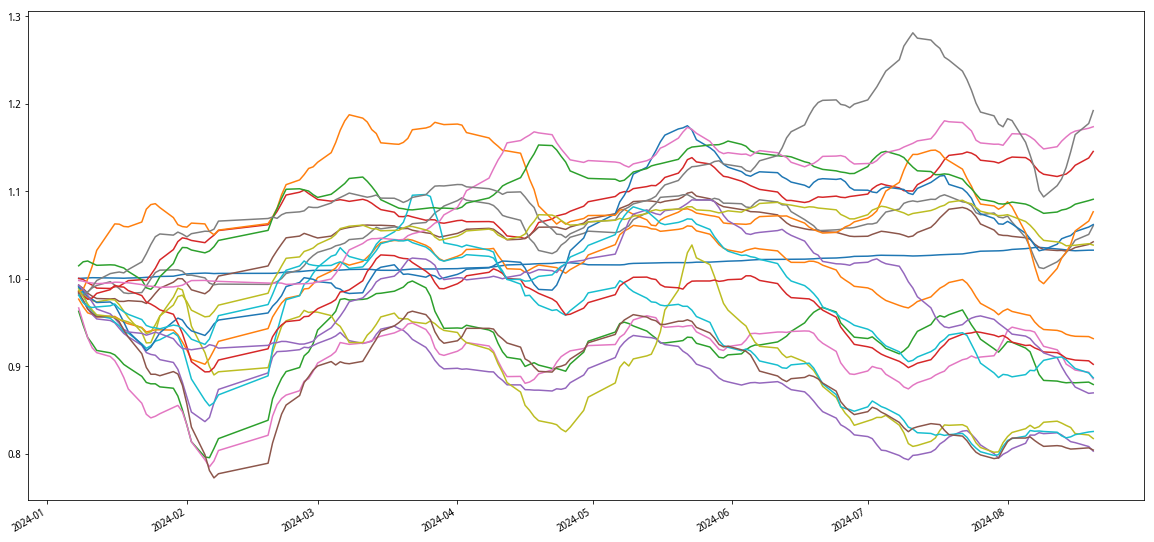

In [15]:
plt.rcParams['figure.figsize'] = [20, 10]
codes = df.code.unique().tolist()
df = []
for code in tqdm(codes):
#     tmp = get_price(code, start_date='2017-01-01', end_date=today, fields=['close', 'low']).dropna()
    tmp = get_price(code, start_date='2024-01-01', end_date=today, fields=['close', 'low']).dropna()
    tmp['close_norm'] = tmp['close'] / tmp['close'].iloc[0]
    tmp['close_norm'] = tmp['close_norm'].rolling(5).mean()
    tmp['close_norm'].plot()
    tmp['code'] = code
    df.append(tmp)
df = pd.concat(df).dropna()